# 02 — Modélisation baseline : `contains_silicones`

Objectif : valider le pipeline de modélisation sur une seule cible avant de généraliser aux 4 autres attributs.

Trois modèles comparés :
1. Features manuelles seules (couleurs, contraste, luminosité)
2. Embeddings CLIP seuls
3. Embeddings CLIP + catégorie (contrôle) — pour vérifier si le signal vient vraiment du packaging ou de la catégorie de produit

In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, classification_report
import matplotlib.pyplot as plt

TARGET = "contains_silicones"
RANDOM_STATE = 42

# Chargement des trois sources
df_meta = pd.read_parquet("../data/processed/dataset_clean.parquet")
df_manual = pd.read_parquet("../data/processed/features_manual.parquet")
embeddings = np.load("../data/processed/embeddings_clip.npy")
embedding_ids = np.load("../data/processed/embeddings_ids.npy")

print("meta:", df_meta.shape, "| manual:", df_manual.shape, "| embeddings:", embeddings.shape)

meta: (1000, 11) | manual: (1000, 11) | embeddings: (1000, 512)


## 1. Jointure et préparation

In [20]:
# Table embeddings alignée avec les ids
df_emb = pd.DataFrame(embeddings, columns=[f"clip_{i}" for i in range(embeddings.shape[1])])
df_emb["id"] = embedding_ids

# Jointure complète : métadonnées + features manuelles + embeddings
df_full = df_meta.merge(df_manual, on="id").merge(df_emb, on="id")
print("Dataset joint :", df_full.shape)

y = df_full[TARGET].astype(int)
print(f"\nDistribution de la cible : {y.value_counts(normalize=True).round(3).to_dict()}")

Dataset joint : (1000, 533)

Distribution de la cible : {0: 0.751, 1: 0.249}


## 2. Split train/test (stratifié)

In [21]:
manual_cols = ["dominant_r", "dominant_g", "dominant_b", "second_r", "second_g", "second_b",
               "contrast", "brightness", "saturation", "aspect_ratio"]
clip_cols = [c for c in df_full.columns if c.startswith("clip_")]

idx_train, idx_test = train_test_split(
    df_full.index, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

y_train, y_test = y.loc[idx_train], y.loc[idx_test]
print(f"Train: {len(idx_train)} | Test: {len(idx_test)}")
print(f"Proportion True train/test : {y_train.mean():.2f} / {y_test.mean():.2f}")

Train: 800 | Test: 200
Proportion True train/test : 0.25 / 0.25


## 3. Modèle 1 — Features manuelles (baseline)

In [22]:
X_manual_train = df_full.loc[idx_train, manual_cols]
X_manual_test = df_full.loc[idx_test, manual_cols]

model_manual = GradientBoostingClassifier(random_state=RANDOM_STATE)
model_manual.fit(X_manual_train, y_train)

proba_manual = model_manual.predict_proba(X_manual_test)[:, 1]
pred_manual = model_manual.predict(X_manual_test)

auc_manual = roc_auc_score(y_test, proba_manual)
f1_manual = f1_score(y_test, pred_manual)
print(f"AUC-ROC (features manuelles) : {auc_manual:.3f}")
print(f"F1 (features manuelles) : {f1_manual:.3f}")

AUC-ROC (features manuelles) : 0.468
F1 (features manuelles) : 0.034


## 4. Modèle 2 — Embeddings CLIP seuls

In [23]:
X_clip_train = df_full.loc[idx_train, clip_cols]
X_clip_test = df_full.loc[idx_test, clip_cols]

scaler = StandardScaler()
X_clip_train_scaled = scaler.fit_transform(X_clip_train)
X_clip_test_scaled = scaler.transform(X_clip_test)

model_clip = LogisticRegression(max_iter=2000, C=0.1, random_state=RANDOM_STATE)
model_clip.fit(X_clip_train_scaled, y_train)

proba_clip = model_clip.predict_proba(X_clip_test_scaled)[:, 1]
pred_clip = model_clip.predict(X_clip_test_scaled)

auc_clip = roc_auc_score(y_test, proba_clip)
f1_clip = f1_score(y_test, pred_clip)
print(f"AUC-ROC (embeddings CLIP) : {auc_clip:.3f}")
print(f"F1 (embeddings CLIP) : {f1_clip:.3f}")

AUC-ROC (embeddings CLIP) : 0.578
F1 (embeddings CLIP) : 0.289


## 5. Modèle 3 — Embeddings CLIP + catégorie (contrôle)

Si l'AUC grimpe fortement ici par rapport au modèle 2, cela suggère que le signal visuel capturé par CLIP recoupe beaucoup l'information de catégorie plutôt que d'apporter un signal indépendant.

In [24]:
category_dummies = pd.get_dummies(df_full["category"], prefix="cat")
df_full_with_cat = pd.concat([df_full, category_dummies], axis=1)
cat_cols = category_dummies.columns.tolist()

X_ctrl_train = df_full_with_cat.loc[idx_train, clip_cols + cat_cols]
X_ctrl_test = df_full_with_cat.loc[idx_test, clip_cols + cat_cols]

scaler_ctrl = StandardScaler()
X_ctrl_train_scaled = scaler_ctrl.fit_transform(X_ctrl_train)
X_ctrl_test_scaled = scaler_ctrl.transform(X_ctrl_test)

model_ctrl = LogisticRegression(max_iter=2000, C=0.1, random_state=RANDOM_STATE)
model_ctrl.fit(X_ctrl_train_scaled, y_train)

proba_ctrl = model_ctrl.predict_proba(X_ctrl_test_scaled)[:, 1]
pred_ctrl = model_ctrl.predict(X_ctrl_test_scaled)

auc_ctrl = roc_auc_score(y_test, proba_ctrl)
f1_ctrl = f1_score(y_test, pred_ctrl)
print(f"AUC-ROC (CLIP + catégorie) : {auc_ctrl:.3f}")
print(f"F1 (CLIP + catégorie) : {f1_ctrl:.3f}")

AUC-ROC (CLIP + catégorie) : 0.611
F1 (CLIP + catégorie) : 0.308


## 6. Modèle de référence — catégorie seule (sans aucune image)

Sert de plancher : si les modèles image ne font pas mieux que ça, l'image n'apporte rien au-delà de la catégorie.

In [25]:
X_cat_train = df_full_with_cat.loc[idx_train, cat_cols]
X_cat_test = df_full_with_cat.loc[idx_test, cat_cols]

model_cat_only = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
model_cat_only.fit(X_cat_train, y_train)

proba_cat_only = model_cat_only.predict_proba(X_cat_test)[:, 1]
auc_cat_only = roc_auc_score(y_test, proba_cat_only)
print(f"AUC-ROC (catégorie seule, sans image) : {auc_cat_only:.3f}")

AUC-ROC (catégorie seule, sans image) : 0.644


## 7. Comparaison récapitulative

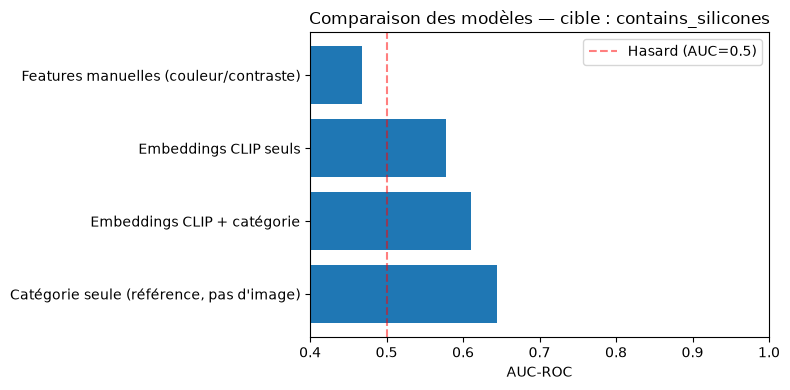

,modèle,AUC-ROC
0,"Catégorie seule (référence, pas d'image)",0.644067
3,Embeddings CLIP + catégorie,0.610667
2,Embeddings CLIP seuls,0.578133
1,Features manuelles (couleur/contraste),0.468267


In [27]:
results = pd.DataFrame({
    "modèle": [
        "Catégorie seule (référence, pas d'image)",
        "Features manuelles (couleur/contraste)",
        "Embeddings CLIP seuls",
        "Embeddings CLIP + catégorie",
    ],
    "AUC-ROC": [auc_cat_only, auc_manual, auc_clip, auc_ctrl],
})
results = results.sort_values("AUC-ROC", ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(results["modèle"], results["AUC-ROC"])
plt.xlim(0.4, 1.0)
plt.axvline(0.5, color="red", linestyle="--", alpha=0.5, label="Hasard (AUC=0.5)")
plt.xlabel("AUC-ROC")
plt.title(f"Comparaison des modèles — cible : {TARGET}")
plt.legend()
plt.tight_layout()
plt.show()

results